<a href="https://colab.research.google.com/github/AiraFarman/ML-CEP/blob/main/CS_20072_Median_Filtering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Roll no: CS-20072  Name: Aira Farman

#### Median Filtering for Grayscale Images

In [ ]:
import numpy
from PIL import Image

def median_filter(data, filter_size):
    temp = []
    indexer = filter_size // 2
    data_final = []
    data_final = numpy.zeros((len(data),len(data[0])))
    for i in range(len(data)):

        for j in range(len(data[0])):

            for z in range(filter_size):
                if i + z - indexer < 0 or i + z - indexer > len(data) - 1:
                    for c in range(filter_size):
                        temp.append(0)
                else:
                    if j + z - indexer < 0 or j + indexer > len(data[0]) - 1:
                        temp.append(0)
                    else:
                        for k in range(filter_size):
                            temp.append(data[i + z - indexer][j + k - indexer])

            temp.sort()
            data_final[i][j] = temp[len(temp) // 2]
            temp = []
    return data_final

def main():
    img = Image.open(r"C:\Users\HS LAPTOP\Downloads\download (1).jpeg").convert(
        "L")
    arr = numpy.array(img)
    removed_noise = median_filter(arr, 3)
    img = Image.fromarray(removed_noise)
    img.show()
main()


grayscale image with salt and pepper noise ![image-3.png](attachment:image-3.png)  with Median Filtering ![image-4.png](attachment:image-4.png)

#### Median Filtering for Color Images

In [ ]:
import numpy as np
from PIL import Image

def median_filter(data, filter_size):
    M, N = filter_size
    modifyA = np.pad(data, ((M//2, M//2), (N//2, N//2), (0, 0)), mode='constant')

    B = np.zeros_like(data)
    # MEDIAN INDEX
    med_indx = (M * N) // 2
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            temp = modifyA[i:i+M, j:j+N]
            # Red, Green, and Blue channels are traversed separately
            for k in range(3):
                tmp = temp[:, :, k]
                B[i, j, k] = np.median(tmp)

    return B.astype(np.uint8)

def main():
    img = Image.open(r"C:\Users\HS LAPTOP\Downloads\rose.jpeg")
    arr = np.array(img)
    removed_noise = median_filter(arr, (3, 3))
    img_filtered = Image.fromarray(removed_noise)
    img_filtered.show()
main()

Color image with salt and pepper noise ![rose.jpeg](attachment:rose.jpeg)  

With median Filtering ![image.png](attachment:image.png)

#### Median Filter with preserving edges (Bilateral Filter)

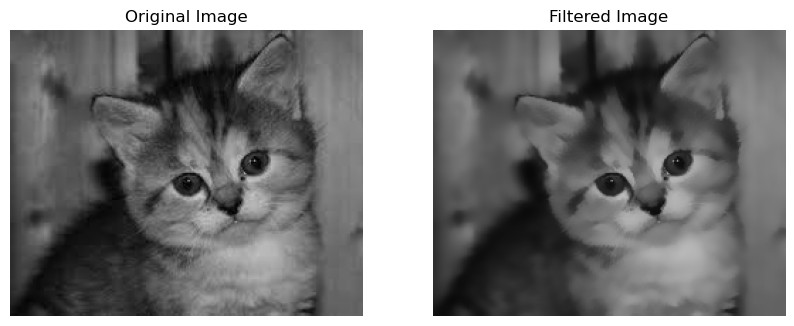

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, sigma):
    return (1.0 / (2 * np.pi * (sigma ** 2))) * np.exp(-((x ** 2) / (2 * (sigma ** 2))))

def distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

def bilateral_filter(image, diameter, sigma_i, sigma_s):
    new_image = np.zeros(image.shape)

    for i in range(len(image)):
        for j in range(len(image[0])):
            wp_total = 0
            filtered_image = 0
            for k in range(diameter):
                for l in range(diameter):
                    n_x = i - (diameter // 2 - k)
                    n_y = j - (diameter // 2 - l)
                    if n_x < 0 or n_x >= len(image):
                        n_x = i
                    if n_y < 0 or n_y >= len(image[0]):
                        n_y = j
                    gi = gaussian(float(image[n_x][n_y]) - float(image[i][j]), sigma_i)
                    gs = gaussian(distance(n_x, n_y, i, j), sigma_s)
                    wp = gi * gs
                    filtered_image += image[n_x][n_y] * wp
                    wp_total += wp
            new_image[i][j] = filtered_image / wp_total

    return new_image.astype(np.uint8)

image = cv2.imread(r"C:\Users\HS LAPTOP\Downloads\images (1).jpeg", 0)
image_own = bilateral_filter(image, 7, 20, 20)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(image_own, cv2.COLOR_RGB2BGR))
plt.title('Filtered Image')
plt.axis('off')

plt.show()
